# Word Speaker Noise word recognition pilot task results

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Import human data

In [5]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/wsn_word_recognition/data/')
!ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("*.json"))

# import vocab dict for matching audio & responses 
word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# ix_to_word_map = {v:k for k,v in class_map.items()}
class_map = word_and_speaker_encodings['word_idx_to_word']

subj_583dd5196bbe2c00017a16d1.json  subj_5f8b4560fc6686262722efdb.json
subj_58dc21fabd5abb000185ee39.json  subj_60fea5c19ec55fb9bb6a09f3.json
subj_5a62207c13898300014b1fbb.json  subj_637ffd0ae752c8e33f91798b.json
subj_5ba740e19629a90001b3b1c5.json  subj_63b80a8b220f924d975670bc.json
subj_5c28cac3867f660001ae9c4a.json  subj_63e51ff21f93dcf52c112028.json
subj_5e14f72f557425b04528df9a.json  subj_641ecfa9f83175a3d9f63636.json
subj_5eac671f0658ac0ea6c730d2.json  subj_76c65zuzax.json
subj_5f162610a5441979433af306.json  subj_ojk3bz8vea.json


In [7]:
eg_part_data = json.load(open(human_fnames[0], 'r'))
eg_df = pd.DataFrame.from_records(eg_part_data)

In [8]:
## Get all subject data into one df for analysis
def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df


dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)
expmnt_trial_str = "dictionary-text"

In [9]:
results_df

,success,timeout,failed_images,failed_audio,failed_video,trial_type,trial_index,time_elapsed,internal_node_id,jspsych_id,...,stimulus,stim_type,hc_answer,hc_correct,response_str,control_trial,correct_response,condition,study_id,session_id
0,True,False,[],[],[],preload,0,114,0.0-0.0,w2l0lo15on,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,instructions,1,2625,0.0-1.0,w2l0lo15on,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,2,8241,0.0-3.0,w2l0lo15on,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,3,16908,0.0-4.0,w2l0lo15on,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,survey-text,4,24886,0.0-5.0,w2l0lo15on,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
914,NaN,NaN,NaN,NaN,NaN,dictionary-text,914,4659923,0.0-12.0-1.0-1.447,6gq2df44y3,...,stim/v01_wsn_eval/condition02/602_000.wav,NaN,NaN,NaN,groups,0.0,related,02,647612757d586329de55dcc9,64762e487851afb7a21b3071
915,NaN,NaN,NaN,NaN,NaN,audio-keyboard-response,915,4662657,0.0-12.0-1.0-0.448,6gq2df44y3,...,stim/v01_wsn_eval/condition01/214_000.wav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,647612757d586329de55dcc9,64762e487851afb7a21b3071
916,NaN,NaN,NaN,NaN,NaN,dictionary-text,916,4664746,0.0-12.0-1.0-1.448,6gq2df44y3,...,stim/v01_wsn_eval/condition01/214_000.wav,NaN,NaN,NaN,great,0.0,great,01,647612757d586329de55dcc9,64762e487851afb7a21b3071
917,NaN,NaN,NaN,NaN,NaN,survey-text,917,4700665,0.0-12.0-2.0,6gq2df44y3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,647612757d586329de55dcc9,64762e487851afb7a21b3071


In [10]:
results_df[results_df.trial_type == "dictionary-text"]

,success,timeout,failed_images,failed_audio,failed_video,trial_type,trial_index,time_elapsed,internal_node_id,jspsych_id,...,stimulus,stim_type,hc_answer,hc_correct,response_str,control_trial,correct_response,condition,study_id,session_id
17,NaN,NaN,NaN,NaN,NaN,dictionary-text,17,92452,0.0-12.0-1.0-1.0,w2l0lo15on,...,stim/v01_wsn_eval/condition01/122_000.wav,NaN,NaN,NaN,day,0.0,before,01,NaN,NaN
19,NaN,NaN,NaN,NaN,NaN,dictionary-text,19,106135,0.0-12.0-1.0-1.1,w2l0lo15on,...,stim/v01_wsn_eval/condition00/435_000.wav,NaN,NaN,NaN,control,0.0,control,00,NaN,NaN
21,NaN,NaN,NaN,NaN,NaN,dictionary-text,21,115638,0.0-12.0-1.0-1.2,w2l0lo15on,...,stim/v01_wsn_eval/condition02/250_000.wav,NaN,NaN,NaN,father,0.0,again,02,NaN,NaN
23,NaN,NaN,NaN,NaN,NaN,dictionary-text,23,122285,0.0-12.0-1.0-1.3,w2l0lo15on,...,stim/v01_wsn_eval/condition00/259_000.wav,NaN,NaN,NaN,various,0.0,various,00,NaN,NaN
25,NaN,NaN,NaN,NaN,NaN,dictionary-text,25,128851,0.0-12.0-1.0-1.4,w2l0lo15on,...,stim/v01_wsn_eval/condition02/628_000.wav,NaN,NaN,NaN,required,0.0,required,02,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
908,NaN,NaN,NaN,NaN,NaN,dictionary-text,908,4644015,0.0-12.0-1.0-1.444,6gq2df44y3,...,stim/v01_wsn_eval/condition00/555_000.wav,NaN,NaN,NaN,things,0.0,things,00,647612757d586329de55dcc9,64762e487851afb7a21b3071
910,NaN,NaN,NaN,NaN,NaN,dictionary-text,910,4648926,0.0-12.0-1.0-1.445,6gq2df44y3,...,stim/v01_wsn_eval/condition01/866_000.wav,NaN,NaN,NaN,direct,0.0,direct,01,647612757d586329de55dcc9,64762e487851afb7a21b3071
912,NaN,NaN,NaN,NaN,NaN,dictionary-text,912,4654627,0.0-12.0-1.0-1.446,6gq2df44y3,...,stim/v01_wsn_eval/condition01/355_000.wav,NaN,NaN,NaN,short,0.0,short,01,647612757d586329de55dcc9,64762e487851afb7a21b3071
914,NaN,NaN,NaN,NaN,NaN,dictionary-text,914,4659923,0.0-12.0-1.0-1.447,6gq2df44y3,...,stim/v01_wsn_eval/condition02/602_000.wav,NaN,NaN,NaN,groups,0.0,related,02,647612757d586329de55dcc9,64762e487851afb7a21b3071


In [11]:
## Map wav str to stim_type using condition dict
import re

# exp_dir = Path('/om2/user/imgriff/projects/Auditory-Attention/behavioral_experiments/commonvoice_word_rec/')
# with open(exp_dir/'pilot_condiition_dict.pkl', 'rb') as handle:
#     stim_cond_map = pickle.load(handle)

# print(stim_cond_map)

stim_cond_map = {"condition00":"clean",
                 "condition01":"stationary_noise", 
                 "condition02":"natural_scene",
    }

def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            condition = stim_cond_map[cond_str]
            return 0, condition 
    return None, None


results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

In [12]:
results_df

,success,timeout,failed_images,failed_audio,failed_video,trial_type,trial_index,time_elapsed,internal_node_id,jspsych_id,...,stim_type,hc_answer,hc_correct,response_str,control_trial,correct_response,condition,study_id,session_id,snr
0,True,False,[],[],[],preload,0,114,0.0-0.0,w2l0lo15on,...,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,instructions,1,2625,0.0-1.0,w2l0lo15on,...,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,2,8241,0.0-3.0,w2l0lo15on,...,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,survey-multi-choice,3,16908,0.0-4.0,w2l0lo15on,...,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,survey-text,4,24886,0.0-5.0,w2l0lo15on,...,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
914,NaN,NaN,NaN,NaN,NaN,dictionary-text,914,4659923,0.0-12.0-1.0-1.447,6gq2df44y3,...,NaN,NaN,NaN,groups,0.0,related,natural_scene,647612757d586329de55dcc9,64762e487851afb7a21b3071,0.0
915,NaN,NaN,NaN,NaN,NaN,audio-keyboard-response,915,4662657,0.0-12.0-1.0-0.448,6gq2df44y3,...,NaN,NaN,NaN,NaN,NaN,NaN,stationary_noise,647612757d586329de55dcc9,64762e487851afb7a21b3071,0.0
916,NaN,NaN,NaN,NaN,NaN,dictionary-text,916,4664746,0.0-12.0-1.0-1.448,6gq2df44y3,...,NaN,NaN,NaN,great,0.0,great,stationary_noise,647612757d586329de55dcc9,64762e487851afb7a21b3071,0.0
917,NaN,NaN,NaN,NaN,NaN,survey-text,917,4700665,0.0-12.0-2.0,6gq2df44y3,...,NaN,NaN,NaN,NaN,NaN,NaN,None,647612757d586329de55dcc9,64762e487851afb7a21b3071,NaN


In [305]:
# model_stim = pd.read_pickle(exp_dir / 'pilot_stimuli_to_condition_manifest.pdpkl')

In [311]:
# model_results = pd.read_csv("attn_cue_models/cv_word_rec_pilot/CommonVoice_attn_task_clean_pilot_cv_clean_word_rec_baseline/version_2/metrics.csv")

In [13]:
# model_results

In [14]:
results_df['accuracy'] = (results_df['response_str'] == results_df['correct_response']).astype('int')
catch_trial_particiapnt_performance = results_df[results_df.control_trial == 1].groupby('jspsych_id').accuracy.mean()
catch_trial_particiapnt_performance

jspsych_id
0dm4u4b2em    1.000000
43yz7f4zgc    0.833333
6gq2df44y3    1.000000
84rsa0g6qk    0.833333
8zems0k9mr    0.833333
d8r28rnn4z    1.000000
mv9qgf3h73    0.000000
paz8moc4g3    0.916667
tak8gsmfn7    1.000000
tq7m369ule    0.833333
w2l0lo15on    1.000000
y4gzxvj1bx    1.000000
y65cfgkpf8    0.833333
yaj3d3dzqn    0.916667
Name: accuracy, dtype: float64

In [62]:
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 10/12].index
print("N good participants ", len(good_participants))

good_results = results_df[results_df.jspsych_id.isin(good_participants)]

N total participants  14
N good participants  13


In [63]:
# get trial data excluding catch trials 
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response_str.isna())]


part_summary_df = (analysis_df.groupby(["snr", 'jspsych_id', "condition"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())



In [64]:
part_summary_df

,snr,jspsych_id,condition,mean
0,0.0,0dm4u4b2em,clean,0.664384
1,0.0,0dm4u4b2em,natural_scene,0.558621
2,0.0,0dm4u4b2em,stationary_noise,0.568493
3,0.0,43yz7f4zgc,clean,0.589041
4,0.0,43yz7f4zgc,natural_scene,0.534247
5,0.0,43yz7f4zgc,stationary_noise,0.510345
6,0.0,6gq2df44y3,clean,0.800000
7,0.0,6gq2df44y3,natural_scene,0.643836
8,0.0,6gq2df44y3,stationary_noise,0.623288
9,0.0,84rsa0g6qk,clean,0.575000


In [65]:
# part_summary_df = part_summary_df[part_summary_df.jspsych_id != 'vgbrx2o3mb']

In [66]:
part_summary_df

,snr,jspsych_id,condition,mean
0,0.0,0dm4u4b2em,clean,0.664384
1,0.0,0dm4u4b2em,natural_scene,0.558621
2,0.0,0dm4u4b2em,stationary_noise,0.568493
3,0.0,43yz7f4zgc,clean,0.589041
4,0.0,43yz7f4zgc,natural_scene,0.534247
5,0.0,43yz7f4zgc,stationary_noise,0.510345
6,0.0,6gq2df44y3,clean,0.800000
7,0.0,6gq2df44y3,natural_scene,0.643836
8,0.0,6gq2df44y3,stationary_noise,0.623288
9,0.0,84rsa0g6qk,clean,0.575000


[Text(0, 0, 'clean'),
 Text(1, 0, 'stationary_noise'),
 Text(2, 0, 'natural_scene')]

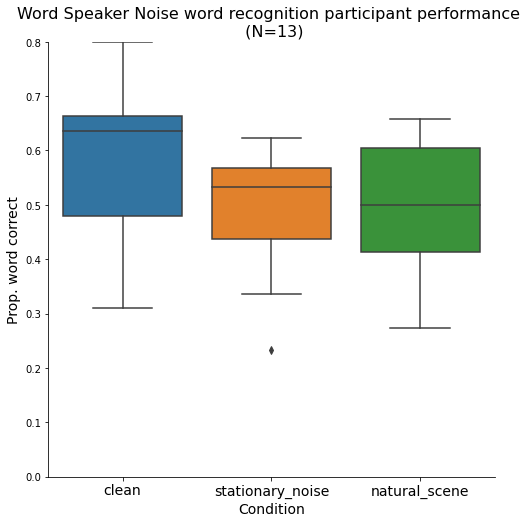

In [67]:
fontsize=14
n_participants = part_summary_df.jspsych_id.unique().shape[0]
fig, axs = plt.subplots(1, figsize=(8,8))

order = ['clean', 'stationary_noise', 'natural_scene']
p = sns.boxplot( data=part_summary_df, x="condition",
                   y="mean",  #error='sem',
                   order=order,
                  #capsize=0.1,
                   ax=axs)

sns.despine()
plt.ylim(0,0.8)
p.set_title(f"Word Speaker Noise word recognition participant performance \n (N={n_participants})",
                 fontsize=fontsize + 2)
p.set_xlabel("Condition",fontsize=fontsize)
p.set_ylabel("Prop. word correct", fontsize=fontsize)

p.set_xticklabels(labels=order, rotation=0, size=fontsize)



[Text(0, 0, 'clean'),
 Text(1, 0, 'stationary_noise'),
 Text(2, 0, 'natural_scene')]

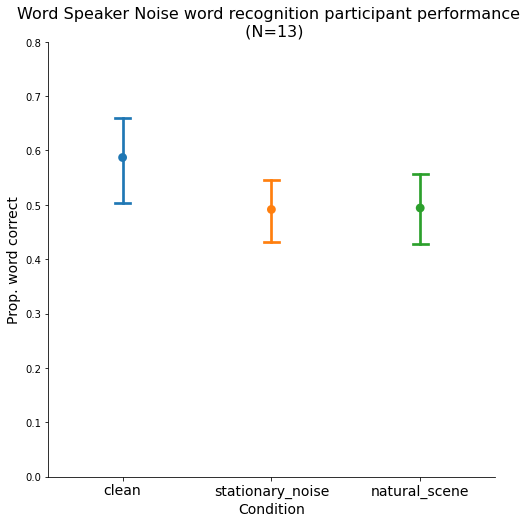

In [68]:
fontsize=14
n_participants = part_summary_df.jspsych_id.unique().shape[0]
fig, axs = plt.subplots(1, figsize=(8,8))


order = ['clean', 'stationary_noise', 'natural_scene']
p = sns.pointplot( kind='point',data=part_summary_df, x="condition",
                   y="mean",  error='sem',
                   order=order,
                   linestyles="None",
                   palette=["tab:blue", "tab:orange", "tab:green"],
                   capsize=0.1,
                   ax=axs)

sns.despine()
plt.ylim(0,0.8)
axs.set_title(f"Word Speaker Noise word recognition participant performance \n (N={n_participants})",
                 fontsize=fontsize + 2)
axs.set_xlabel("Condition",fontsize=fontsize)
axs.set_ylabel("Prop. word correct", fontsize=fontsize)

p.set_xticklabels(labels=order, rotation=0, size=fontsize)



In [22]:
source_df = pd.read_pickle("/om2/user/msaddler/spatial_audio_pipeline/assets/wsn/manifest_JSIN_behavioral_unique_speech.pdpkl")

In [23]:
source_df

,client_id,clip_dur_in_s,clip_end_in_s,clip_start_in_s,corpus,corpus_int,label_talker_int,label_word_int,path,split,split_int,sr,src_fn,talker_int,total_file_duration_in_s,word,word_int
0,46e,0.50,4.76,4.26,wsj,2,14,644,/home/raygon/projects/user/jfeather/jsinDatase...,eval,2,16000,/om/data/public/wall-street-journal/csr_2_comp...,13,10.525500,shares,643
30,ljl,0.35,251.48,251.13,swc,1,227,419,/home/raygon/deepFerret/data/sources/speech/sw...,eval,2,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,226,282.393832,meaning,418
60,viktor-o-ledenyov,0.47,1246.34,1245.87,swc,1,308,681,/home/raygon/deepFerret/data/sources/speech/sw...,eval,2,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,307,2069.366712,stated,680
90,thevoicebeforethevoid,0.29,18.86,18.57,swc,1,296,51,/home/raygon/deepFerret/data/sources/speech/sw...,eval,2,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,295,1425.587664,april,50
120,willmcw,0.37,798.57,798.20,swc,1,317,271,/home/raygon/deepFerret/data/sources/speech/sw...,eval,2,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,316,1739.858141,following,270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23640,batwoodman,0.41,2090.46,2090.05,swc,1,160,512,/home/raygon/deepFerret/data/sources/speech/sw...,eval,2,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,159,7148.244172,playing,511
23670,46y,0.35,4.05,3.70,wsj,2,30,222,/home/raygon/projects/user/jfeather/jsinDatase...,eval,2,16000,/om/data/public/wall-street-journal/csr_2_comp...,29,6.939375,effect,221
23700,salsasam,0.37,1193.74,1193.37,swc,1,271,673,/home/raygon/deepFerret/data/sources/speech/sw...,eval,2,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,270,3334.353560,spread,672
23730,gonzonoir,0.65,461.42,460.77,swc,1,198,634,/home/raygon/deepFerret/data/sources/speech/sw...,eval,2,44100,/scratch2/weka/mcdermott/msaddler/swc/english/...,197,1206.266485,september,633
